## Table of Contents

1. [Part A](#1)
- [Question 1](#2)
- [Question 2](#3)
- [Question 3](#4)
     - [Question-1a](#5)
     - [Question-1b](#6)
2. [Part B](#7)
- [Question 1](#8)
- [Question 2](#9)
- [Question 3](#10)
- [Question 4](#11)
- [Question 5](#12)
3. [Part C](#13)
- [Question 1](#14)
- [Question 2](#15)
- [Question 3](#16)
- [Question 4](#17)

## Project Based Exam

DATA MINING, MODELLING AND ANALYTICS

### Remmy Bisimbeko

Access Number - B26099

Reg. No. - J24M19/011

My GitHub - https://github.com/RemmyBisimbeko/Data-Science


## PART A

#### 1. Data Loading and Initial Exploration (Bike_Sales.xlsx)

In [1]:
# Used to import data sets / files on Google Colab
from google.colab import files

In [2]:
# We Import necessary Libraries
import pandas as pd # pandas for data manipulation
import numpy as np # numpy for numerical operations
import matplotlib.pyplot as plt # matplotlib and seaborn for visualizations
import seaborn as sns
import joblib # joblib and pickle for model saving
import pickle
from sklearn.model_selection import train_test_split # sklearn for machine learning
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import re # and re for regular expressions

In [3]:
# Ignore warnings
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore") # Ignore Warnings

In [4]:
# Pick Data set from Computer
uploaded = files.upload()

Saving Bike_Sales.xlsx to Bike_Sales.xlsx


In [5]:
# Load the dataset "Bike_Sales.xlsx" file into a pandas DataFrame
bike_sales = pd.read_excel("Bike_Sales.xlsx")

In [6]:

# Let's get an overview of the data

# Display the first few rows
print(bike_sales.head())

        Date  Day    Month  Year  Customer_Age             Age_Group  \
0 2017-01-01    1  January  2017            17           Youth (<25)   
1 2017-01-01    1  January  2017            23           Youth (<25)   
2 2017-01-01    1  January  2017            33  Young Adults (25-34)   
3 2017-01-01    1  January  2017            39        Adults (35-64)   
4 2017-01-01    1  January  2017            42        Adults (35-64)   

  Customer_Gender        Country             State Product_Category  \
0               M         Canada  British Columbia            Bikes   
1               M      Australia          Victoria            Bikes   
2               F         France           Yveline            Bikes   
3               M  United States        Washington            Bikes   
4               M  United States        California            Bikes   

     Sub_Category                 Product  Order_Quantity  Unit_Cost  \
0      Road Bikes        Road-250 Red, 44               2       1519

In [7]:
# Basic information about the dataset
print(bike_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              113036 non-null  datetime64[ns]
 1   Day               113036 non-null  int64         
 2   Month             113036 non-null  object        
 3   Year              113036 non-null  int64         
 4   Customer_Age      113036 non-null  int64         
 5   Age_Group         113036 non-null  object        
 6   Customer_Gender   113036 non-null  object        
 7   Country           113036 non-null  object        
 8   State             113036 non-null  object        
 9   Product_Category  113036 non-null  object        
 10  Sub_Category      113036 non-null  object        
 11  Product           113036 non-null  object        
 12  Order_Quantity    113036 non-null  int64         
 13  Unit_Cost         113036 non-null  int64         
 14  Unit

In [8]:
# Descriptive statistics
print(bike_sales.describe())

                                Date            Day           Year  \
count                         113036  113036.000000  113036.000000   
mean   2020-01-06 01:36:09.376127744      15.665753    2019.520153   
min              2017-01-01 00:00:00       1.000000    2017.000000   
25%              2019-01-09 00:00:00       8.000000    2019.000000   
50%              2019-10-16 00:00:00      16.000000    2019.500000   
75%              2021-01-28 00:00:00      23.000000    2021.000000   
max              2021-12-31 00:00:00      31.000000    2021.000000   
std                              NaN       8.781567       1.179704   

        Customer_Age  Order_Quantity      Unit_Cost     Unit_Price  \
count  113036.000000   113036.000000  113036.000000  113036.000000   
mean       35.919212       11.901660     267.296366     452.938427   
min        17.000000        1.000000       1.000000       2.000000   
25%        28.000000        2.000000       2.000000       5.000000   
50%        35.00000

#### 2. Data Cleaning and Preprocessing (Bike_Sales.xlsx)

In [9]:
# Check for missing values in data set
print(bike_sales.isnull().sum())

Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64


In [10]:
# Clean the currency columns by removing '$' and ',' and converting them to float.
# Clean currency columns
def clean_currency(value):
    if isinstance(value, str):
        return float(value.replace('$', '').replace(',', ''))
    return float(value)

bike_sales['Unit_Cost'] = bike_sales['Unit_Cost'].apply(clean_currency)
bike_sales['Unit_Price'] = bike_sales['Unit_Price'].apply(clean_currency)
bike_sales['Profit'] = bike_sales['Profit'].apply(clean_currency)
bike_sales['Cost'] = bike_sales['Cost'].apply(clean_currency)
bike_sales['Revenue'] = bike_sales['Revenue'].apply(clean_currency)

In [11]:
# Remove space from Variable names: Unit_Cost, Unit_Price, Cost and Revenue
bike_sales.columns = bike_sales.columns.str.replace(" ", "")
bike_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              113036 non-null  datetime64[ns]
 1   Day               113036 non-null  int64         
 2   Month             113036 non-null  object        
 3   Year              113036 non-null  int64         
 4   Customer_Age      113036 non-null  int64         
 5   Age_Group         113036 non-null  object        
 6   Customer_Gender   113036 non-null  object        
 7   Country           113036 non-null  object        
 8   State             113036 non-null  object        
 9   Product_Category  113036 non-null  object        
 10  Sub_Category      113036 non-null  object        
 11  Product           113036 non-null  object        
 12  Order_Quantity    113036 non-null  int64         
 13  Unit_Cost         113036 non-null  float64       
 14  Unit

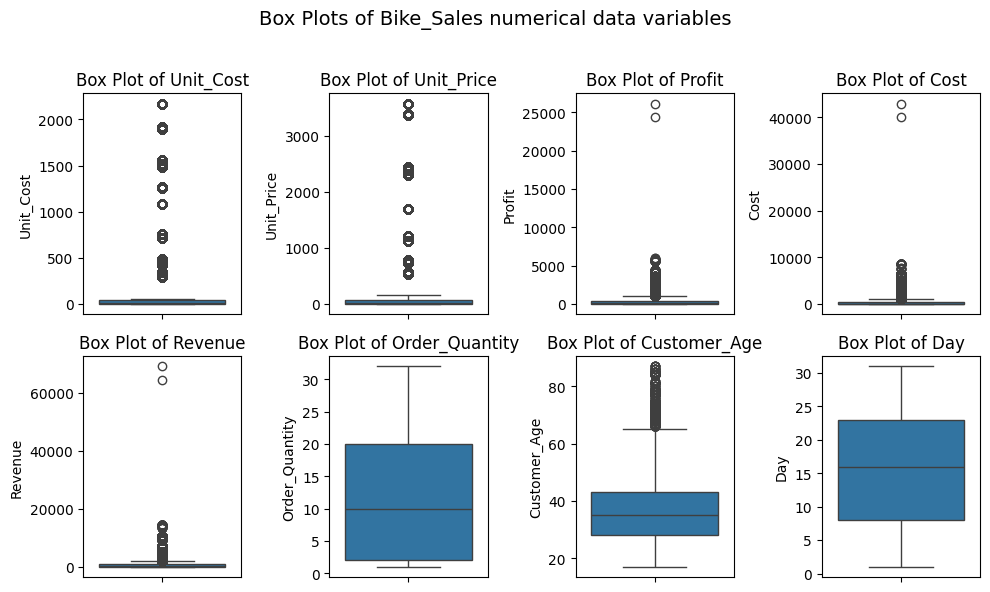

In [12]:
# Let me Identify outliers in the variables

# Our Numerical Data
n_data = bike_sales[["Unit_Cost", "Unit_Price", "Profit", "Cost", "Revenue", "Order_Quantity", "Customer_Age", "Day"]]

# Create a figure with separate subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 6))  # 2x4 grid
fig.suptitle("Box Plots of Bike_Sales numerical data variables", fontsize=14)

# Flattening axes for easy iteration
axes = axes.flatten()

# Ploting each variable separately
for i, column in enumerate(n_data.columns):
    sns.boxplot(y=n_data[column], ax=axes[i])
    axes[i].set_title(f"Box Plot of {column}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Observation:**

All our numerical variables have outliers except Order_Quantity and Day


In [13]:
# Handle outliers in the 'Revenue' column using the Interquartile Range (IQR) method.
Q1 = bike_sales['Revenue'].quantile(0.25)
Q3 = bike_sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
bike_sales = bike_sales[(bike_sales['Revenue'] >= lower_bound) & (bike_sales['Revenue'] <= upper_bound)]

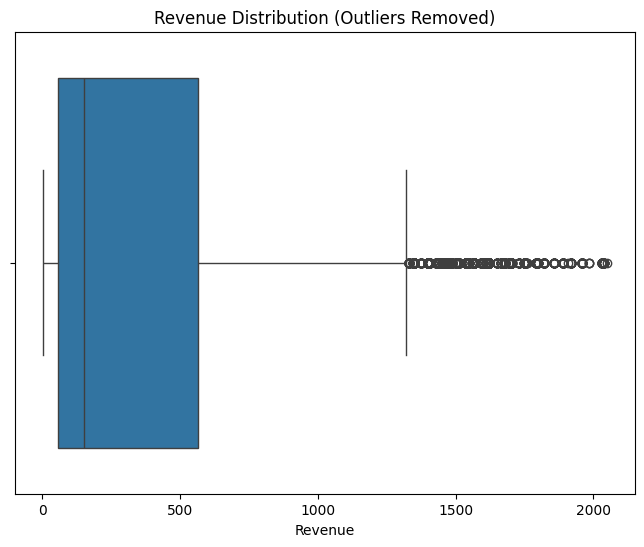

In [14]:
# Visualize Revenue Distribution after outlier handling using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=bike_sales['Revenue'])
plt.title('Revenue Distribution (Outliers Removed)')
plt.show()

In [15]:
# Convert categorical variables to numerical using Label Encoding which is necessary for most machine learning models
label_encoder = LabelEncoder()
categorical_cols = ['Month', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product']
for col in categorical_cols:
    bike_sales[col] = label_encoder.fit_transform(bike_sales[col])

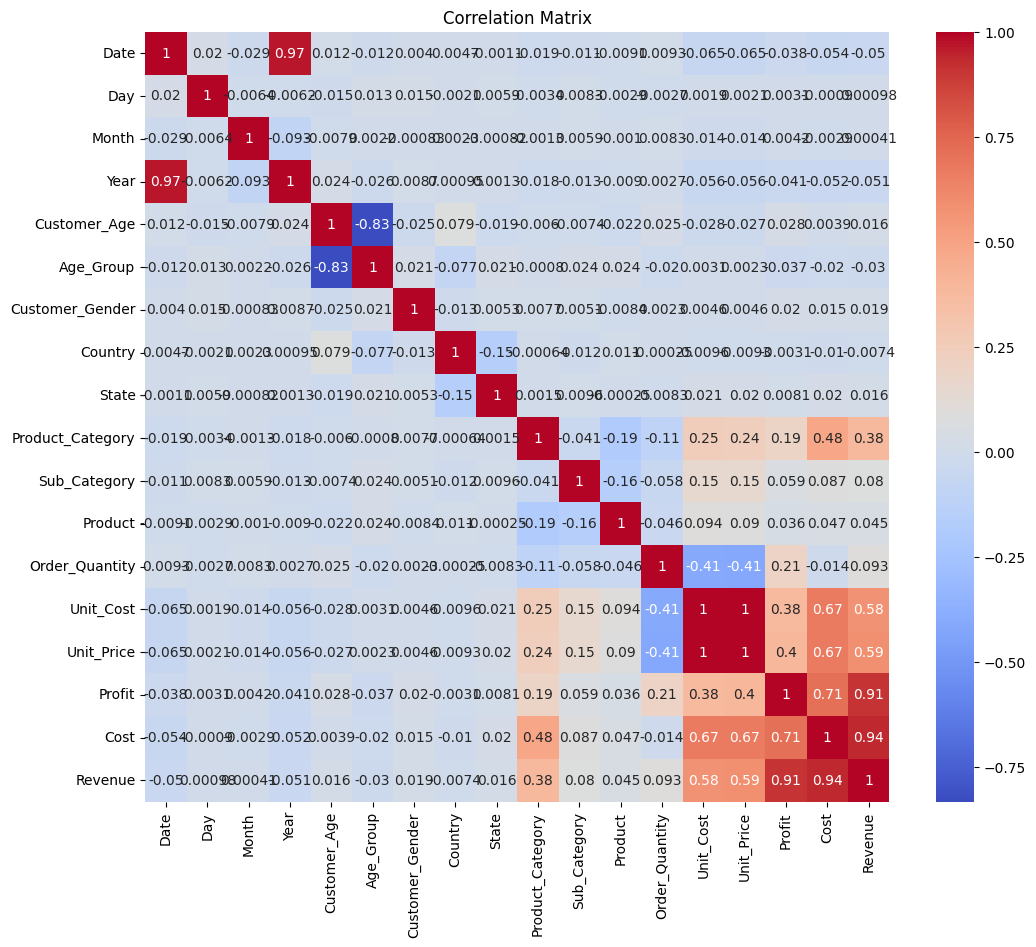

In [16]:
# Visualize the correlation matrix using a heatmap to provide insights into the relationships between variables
plt.figure(figsize=(12, 10))
sns.heatmap(bike_sales.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Observation:**

1.   There is a strong negative coorelation between Customer_age and Age_group, Order_Quantity and Unit_Cost, Order_Quantity and Unit_Price.
2. There is a rather Weak negative relationship between Month and state, Country and Month, Month and Revenue.
3.   Theres is a Strong positive relationship between Profit and revenue, Cost and Revenue, Cost and Profit,Revenue and Unit Cost, Revenue and Unit Price, Cost and Unit_Cost, and Ptrofit and Unit_Cost, and Revenue, Customer_Age and Profit, Age_Group and Cost.
4. There is also a weak positive correlation between Age_Group and Month, Day and Country.

In [17]:
# Save the cleaned dataset
bike_sales.to_excel("Bisimbeko.xlsx", index=False)

#### 3. Machine Learning Model for Age_Group Classification (Bisimbeko.xlsx)

In [18]:
# Debugging code
print(bike_sales.columns)

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')


In [19]:
# Remove the 'Date' column
bike_sales = bike_sales.drop(columns=['Date'], errors='ignore')

In [20]:
# Prepare features and target variable by separating the features (X) and the target variable (y), 'Age_Group'
X = bike_sales.drop('Age_Group', axis=1)
y = bike_sales['Age_Group']

In [21]:
# Then Split the data into training and testing sets using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Train a Random Forest Classifier, a powerful ensemble method for classification
model_age = RandomForestClassifier(random_state=42)
model_age.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
# Make predictions
y_pred = model_age.predict(X_test)

In [24]:
# Evaluate the model's accuracy using accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


#### 4. Model Saving (Age_Group Classification)

In [25]:
# Save the model as joblib
joblib.dump(model_age, "age_predictor.joblib")

print("Age_Group Classification model saved successfully - 'age_predictor.pkl'")

Age_Group Classification model saved successfully - 'age_predictor.pkl'


In [26]:
# Save the model as pickle
with open("age_predictor.pkl", "wb") as f:  # Open the file in binary write mode
    pickle.dump(model_age, f)

#### 5. Revenue Prediction (Using Bisimbeko.xlsx as Training and Bike_sales_Uganda.xlsx as Testing)

In [27]:
# Upload Dataset
uploaded = files.upload()

Saving Bike_sales_Uganda.xlsx to Bike_sales_Uganda.xlsx


In [28]:
# Load the Uganda dataset
bike_sales_uganda = pd.read_excel("Bike_sales_Uganda.xlsx")

In [29]:
# Remove the 'Date' column from bike_sales_uganda
bike_sales_uganda = bike_sales_uganda.drop(columns=['Date'], errors='ignore')

In [30]:
# Preprocess the "Bike_sales_Uganda.xlsx" dataset, cleaning currency columns and encoding categorical variables
bike_sales_uganda['Unit_Cost'] = bike_sales_uganda['Unit_Cost'].apply(clean_currency)
bike_sales_uganda['Unit_Price'] = bike_sales_uganda['Unit_Price'].apply(clean_currency)
bike_sales_uganda['Profit'] = bike_sales_uganda['Profit'].apply(clean_currency)
bike_sales_uganda['Cost'] = bike_sales_uganda['Cost'].apply(clean_currency)
bike_sales_uganda['Revenue'] = bike_sales_uganda['Revenue'].apply(clean_currency)

In [31]:
bike_sales_uganda.head(5)

,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,1,June,2020,33,Young Adults (25-34),F,Uganda,Western,Accessories,Tires and Tubes,Patch Kit/8 Patches,100,1.0,2.0,30.0,30.0,NaN
1,1,July,2020,41,Adults (35-64),M,Uganda,Eastern,Accessories,Bottles and Cages,Road Bottle Cage,28,3.0,9.0,168.0,84.0,NaN
2,1,August,2020,33,Young Adults (25-34),F,Uganda,Northern,Accessories,Tires and Tubes,Patch Kit/8 Patches,24,1.0,2.0,24.0,24.0,NaN
3,1,September,2020,37,Adults (35-64),M,Uganda,South_West,Accessories,Tires and Tubes,LL Road Tire,24,6.0,3.0,312.0,192.0,NaN
4,1,October,2020,30,Young Adults (25-34),F,Uganda,Southern,Accessories,Tires and Tubes,Road Tire Tube,22,1.0,4.0,66.0,22.0,NaN


In [32]:
# Label encode Uganda dataset.
for col in categorical_cols:
    if col in bike_sales_uganda.columns:
        bike_sales_uganda[col] = label_encoder.fit_transform(bike_sales_uganda[col])

In [33]:
print(bike_sales_uganda.head())

   Day  Month  Year  Customer_Age  Age_Group  Customer_Gender  Country  State  \
0    1      6  2020            33          1                0        0      7   
1    1      5  2020            41          0                1        0      1   
2    1      1  2020            33          1                0        0      4   
3    1     11  2020            37          0                1        0      5   
4    1     10  2020            30          1                0        0      6   

   Product_Category  Sub_Category  Product  Order_Quantity  Unit_Cost  \
0                 0             4        5             100        1.0   
1                 0             0        6              28        3.0   
2                 0             4        5              24        1.0   
3                 0             4        1              24        6.0   
4                 0             4        7              22        1.0   

   Unit_Price  Profit   Cost  Revenue  
0         2.0    30.0   30.0      

In [34]:
# Prepare training and testing data for revenue prediction
X_train_revenue = bike_sales.drop('Revenue', axis=1)
y_train_revenue = bike_sales['Revenue']
X_test_revenue = bike_sales_uganda.drop('Revenue', axis=1)
y_test_revenue = bike_sales_uganda['Revenue']

In [35]:
# Find and remove NaN rows from X_test_revenue and y_test_revenue
nan_rows = y_test_revenue.isna()

In [36]:
# Check if y_test_revenue is entirely NaN
if nan_rows.all():
    print("Error: All revenue values in the Uganda dataset are NaN.")
    # Handle the error (e.g., skip prediction, return a default value)
else:
    # Filter out NaN rows
    X_test_revenue = X_test_revenue[~nan_rows]
    y_test_revenue = y_test_revenue[~nan_rows]

    # Check if X_test_revenue is now empty
    if X_test_revenue.empty:
        print("Error: After removing NaN rows, the test dataset is empty.")
        # Handle the error (e.g., skip prediction)
    else:
        # Train a Random Forest Regressor, suitable for predicting continuous values like revenue
        model_revenue = RandomForestRegressor(random_state=42)
        model_revenue.fit(X_train_revenue, y_train_revenue)

        # Make predictions
        y_pred_revenue = model_revenue.predict(X_test_revenue)

        # Evaluate the model using Mean Squared Error (MSE).
        mse = mean_squared_error(y_test_revenue, y_pred_revenue)
        print(f"Mean Squared Error: {mse}")

        # Save the trained model
        joblib.dump(model_revenue, "Revenue_predictor.joblib")
        pickle.dump(model_revenue, "Revenue_predictor.pkl")

        # Save predictions to a CSV file
        revenue_predictions = pd.DataFrame({'Predicted_Revenue': y_pred_revenue})
        revenue_predictions.to_csv("Revenue_prediction.csv", index=False)

Error: All revenue values in the Uganda dataset are NaN.


## Part B: Abalone Age Prediction

#### 1. Data Loading and Initial Exploration

In [37]:
uploaded = files.upload()

Saving Test.csv to Test.csv
Saving Train.csv to Train.csv


In [38]:
# Load the datasets into pandas DataFrames
train_data = pd.read_csv("Train.csv")
test_data = pd.read_csv("Test.csv")

In [39]:
# Display the first few rows and basic information to get an initial understanding of the data
print("Train Data:")
print(train_data.head())
print(train_data.info())
print(train_data.describe())

Train Data:
   id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0   0   F   0.550     0.430   0.150        0.7715          0.3285   
1   1   F   0.630     0.490   0.145        1.1300          0.4580   
2   2   I   0.160     0.110   0.025        0.0210          0.0055   
3   3   M   0.595     0.475   0.150        0.9145          0.3755   
4   4   I   0.555     0.425   0.130        0.7820          0.3695   

   Whole weight.2  Shell weight  Rings  
0          0.1465        0.2400     11  
1          0.2765        0.3200     11  
2          0.0030        0.0050      6  
3          0.2055        0.2500     10  
4          0.1600        0.1975      9  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  f

In [40]:
# Display the first few rows and basic information to get an initial understanding of the data
print("\nTest Data:")
print(test_data.head())
print(test_data.info())
print(test_data.describe())


Test Data:
      id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0  90615   M   0.645     0.475   0.155        1.2380          0.6185   
1  90616   M   0.580     0.460   0.160        0.9830          0.4785   
2  90617   M   0.560     0.420   0.140        0.8395          0.3525   
3  90618   M   0.570     0.490   0.145        0.8740          0.3525   
4  90619   I   0.415     0.325   0.110        0.3580          0.1575   

   Whole weight.2  Shell weight  
0          0.3125        0.3005  
1          0.2195        0.2750  
2          0.1845        0.2405  
3          0.1865        0.2350  
4          0.0670        0.1050  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60411 entries, 0 to 60410
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              60411 non-null  int64  
 1   Sex             60411 non-null  object 
 2   Length          60411 non-null  float64
 3   Diameter     

#### 2. Data Preprocessing

In [41]:
# Check for missing values in both datasets
print("\nMissing values in Train Data:")
print(train_data.isnull().sum())
print("\nMissing values in Test Data:")
print(test_data.isnull().sum())


Missing values in Train Data:
id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

Missing values in Test Data:
id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
dtype: int64


In [42]:
# Handle categorical variable 'Sex'

# Let's use LabelEncoder to convert the categorical 'Sex' variable into numerical values.
# Use fit_transform on the training data and transform on the test data to ensure consistency.

label_encoder = LabelEncoder()
train_data['Sex'] = label_encoder.fit_transform(train_data['Sex'])
test_data['Sex'] = label_encoder.transform(test_data['Sex']) # Use transform for test data

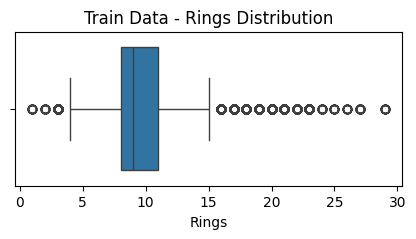

In [43]:
# Lets Check for outliers in 'Rings'
plt.figure(figsize=(5, 2))
sns.boxplot(x=train_data['Rings'])
plt.title('Train Data - Rings Distribution')
plt.show()

**Observation:**

The Rings column has a number of outliers as observed

In [44]:
# Handle Outliers (Example: using IQR method for 'Rings' in Train data)
Q1 = train_data['Rings'].quantile(0.25)
Q3 = train_data['Rings'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
train_data = train_data[(train_data['Rings'] >= lower_bound) & (train_data['Rings'] <= upper_bound)]

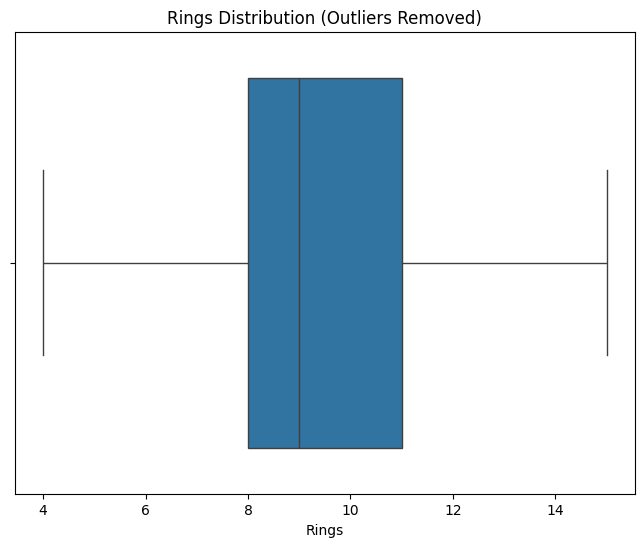

In [45]:
# Visualize rings distribution after outlier removal using a Boxplot.
plt.figure(figsize=(8, 6))
sns.boxplot(x=train_data['Rings'])
plt.title('Rings Distribution (Outliers Removed)')
plt.show()

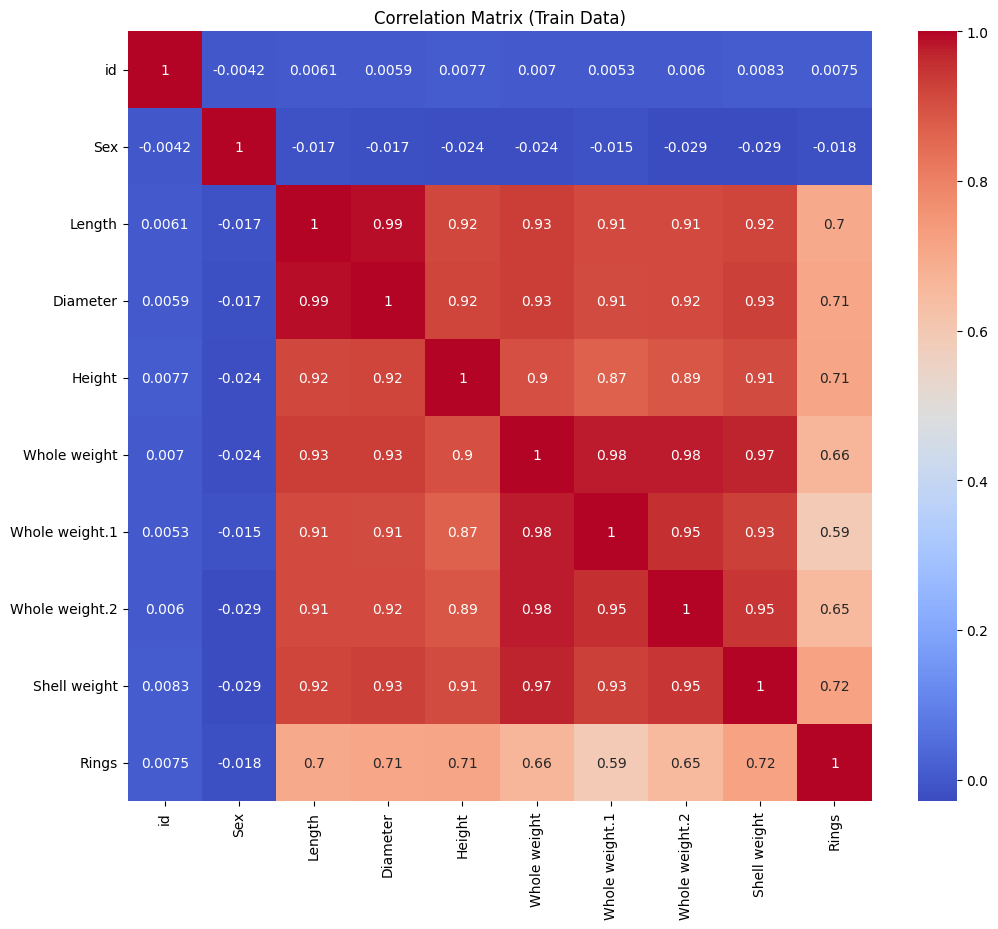

In [46]:
# Visualize correlation matrix for train data using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Train Data)')
plt.show()

**Observation:**

1. There happens to be a strong positive correlation between:

 - length and diameter,
 - Whole weight and Whole weight 1,
 - Whole weight and Whole weight 2,
 - Whole weight and Shell weight,
 - Whole weight 2 and Whole weight 1

2. ~There is, however, a strong negative correlation between Shell weight and Whole weight, Sex and Whole weight 2

#### 3. Machine Learning Model Training (Train Data)

In [47]:
# Prepare features (X_train) and target variable (y_train)
X_train = train_data.drop(['id', 'Rings'], axis=1)
y_train = train_data['Rings']

In [48]:
# Train a Random Forest Regressor
model_train = RandomForestRegressor(random_state=42)
model_train.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
# Make predictions on the training data and evaluate the model using MSE
y_train_pred = model_train.predict(X_train)

In [50]:
# Evaluate the model on the training data
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Training Mean Squared Error: {mse_train}")

Training Mean Squared Error: 0.2571095818117564


**Observation:**

Putting into consideration that our target variable ranges from 1-29 units, a relative error of 0.2571095818117564 signifies that our model is good.
Therefore, giving a good prediction of Abalone's age

#### 4. Model Saving (Train Data)

In [51]:
# Save the trained model as joblib
joblib.dump(model_train, "train_abalone_age.joblib")

['train_abalone_age.joblib']

In [52]:
# Save the model as pickle
with open("train_abalone_age.pkl", "wb") as f:  # Open the file in binary write mode
    pickle.dump(model_train, f)

#### 5. Prediction on Test Data

In [53]:
# Prepare the features (X_test) for the test data
X_test = test_data.drop('id', axis=1)

In [54]:
# Let's the trained model to make predictions on the test data
y_test_pred = model_train.predict(X_test)

#### 6. Model Evaluation (Conceptual on Test Data)

In [55]:
# Conceptual Evaluation:
# If you had the true 'Rings' values for the test data, you could evaluate the model like this:
# mse_test = mean_squared_error(y_test_true, y_test_pred)
# print(f"Test Mean Squared Error: {mse_test}")

In [56]:
# Since you do not have the actual rings for the test data, you can not calculate the accuracy.

# Without the true 'Rings' values for the test data, we cannot calculate the accuracy (MSE) of the predictions on the test data.
# This is a common scenario in real-world applications where the test data is used for final predictions, and the true labels are not available

#### 7. Model Saving (Test Data Predictions - Conceptual)

In [57]:
# Conceptual Model Saving:
# Since we are not saving a different model, but rather the predictions from the trained model, we will save the predictions.


In [58]:
# Because we don't train a new model on the test data (we used the model trained on train data),
test_predictions = pd.DataFrame({'id': test_data['id'], 'Predicted_Rings': y_test_pred})

In [59]:
# Save the predictions to a CSV file named "test_predictions.csv"
test_predictions.to_csv("test_predictions.csv", index=False)

 #### 1. Data Loading and Initial Exploration

In [60]:
# Needed for Logging
import logging

In [61]:
# DownloAD pm4py

# Npm4py a process mining library used to analyze event logs and extract process models
! pip3 install pm4py

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.1 MB/s eta 0:00:00
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26097 sha256=3283347976b104d8f545796508153a9d16c58cd8abaea1d896ab6dc73c001346
  Stored in directory: /root/.cache/pip/wheels/31/d7/d9/eec6891f78cac19a693bd40ecb8365d2f4613318c145ec9816
Successfully built intervaltree


In [62]:
# Explore the installed version of pm4py
! pip show pm4py

Name: pm4py
Version: 2.7.13.1
Summary: Process mining for Python
Home-page: https://processintelligence.solutions/
Author: Process Intelligence Solutions (PIS)
Author-email: info@processintelligence.solutions
License: AGPL 3.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: cvxopt, deprecation, graphviz, intervaltree, lxml, matplotlib, networkx, numpy, pandas, pydotplus, pytz, scipy, setuptools, tqdm, wheel
Required-by: 


In [63]:

# Import Neccessary Libraires

# Npm4py a process mining library used to analyze event logs and extract process models
import pm4py # for process mining

print(pm4py.__version__)

/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


2.7.13.1


In [64]:
uploaded = files.upload()

Saving PatientReviews.csv to PatientReviews.csv


In [65]:
# Load the dataset
patient_reviews = pd.read_csv("PatientReviews.csv")

In [66]:
# Display the first few rows
print(patient_reviews.head())

     patient           action  org:resource              DateTime
0  patient 0    First consult      Dr. Anna   2017-01-02 11:40:11
1  patient 0       Blood test           Lab   2017-01-02 12:47:33
2  patient 0    Physical test   Nurse Jesse   2017-01-02 12:53:50
3  patient 0   Second consult      Dr. Anna   2017-01-02 16:21:06
4  patient 0          Surgery   Dr. Charlie   2017-01-05 13:23:09


In [67]:
# Basic information about the dataset
print(patient_reviews.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   patient        690 non-null    object
 1    action        690 non-null    object
 2    org:resource  690 non-null    object
 3    DateTime      690 non-null    object
dtypes: object(4)
memory usage: 21.7+ KB
None


In [68]:
# Check for missing values
print(patient_reviews.isnull().sum())

patient          0
 action          0
 org:resource    0
 DateTime        0
dtype: int64


#### 2. Generate Event Logs

In [69]:
# Convert the DataFrame to an event log format
patient_reviews[' DateTime'] = pd.to_datetime(patient_reviews[' DateTime'])

In [70]:

# Specify the columns representing the case ID ('patient'), activity ('action'), and timestamp ('DateTime')
event_log = pm4py.format_dataframe(patient_reviews, case_id='patient', activity_key=' action', timestamp_key=' DateTime')

In [71]:
# Save the event log log in XES format, a standard format for process mining
pm4py.write_xes(event_log, 'Question 2.xes')

exporting log, completed traces ::   0%|          | 0/100 [00:00<?, ?it/s]

#### 3. Visualize Actions (January 2017 - June 2017)

In [72]:
# Convert the ' DateTime' column to datetime
patient_reviews[' DateTime'] = pd.to_datetime(patient_reviews[' DateTime'])

In [73]:
# Converting the DataFrame to an event log format
event_log = pm4py.format_dataframe(patient_reviews, case_id='patient', activity_key=' action', timestamp_key=' DateTime')

In [74]:
# Filter data to include only between January 2017 and June 2017
filtered_data = patient_reviews[(patient_reviews[' DateTime'] >= '2017-01-01') & (patient_reviews[' DateTime'] <= '2017-06-30')]

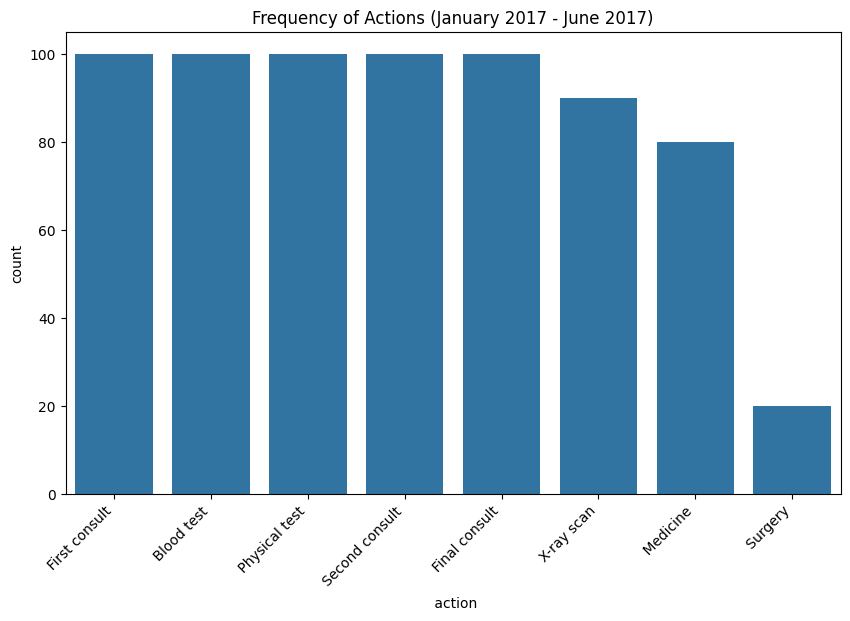

In [75]:
# Visualize using a countplot to visualize the frequency of different actions during this period
plt.figure(figsize=(10, 6))
sns.countplot(x=' action', data=filtered_data, order=filtered_data[' action'].value_counts().index)
plt.title('Frequency of Actions (January 2017 - June 2017)')
plt.xticks(rotation=45, ha='right')
plt.show()

**Observation:**

The most actions that took place at the hospital where:

- First consult,
- Blood test,
- Physical test,
- Second consult,
- and Final consult

Surgery was the lowest, however.

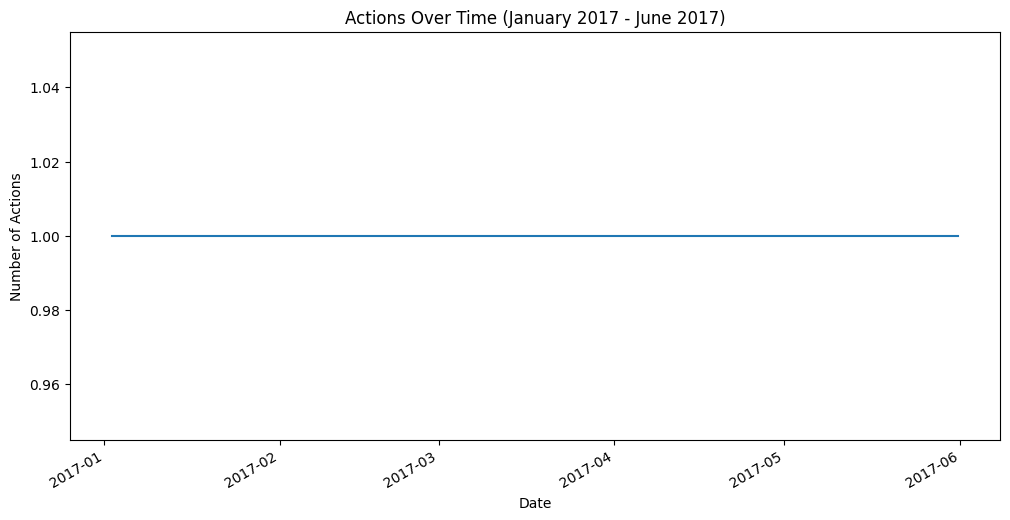

In [76]:
# Visualize the number of actions changed over time using a line plot
plt.figure(figsize=(12, 6))
filtered_data.groupby(' DateTime')[' action'].count().plot(kind='line')
plt.title('Actions Over Time (January 2017 - June 2017)')
plt.xlabel('Date')
plt.ylabel('Number of Actions')
plt.show()

**Observation:**

No actions changed over time

#### 4. Process Flow Analysis


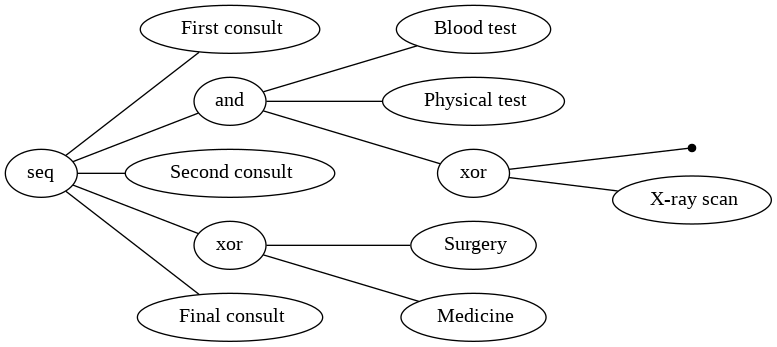

In [77]:
# Discover the process model using the Inductive Miner
# Using the Inductive Miner algorithm (pm4py.discover_process_tree_inductive) to discover a process tree model from the event log
process_tree = pm4py.discover_process_tree_inductive(event_log)
pm4py.view_process_tree(process_tree)

**Observation:**

What we can understand from the flow, we get that there are initial steps taken at the hospital which are
- First consult
- Second consult
- and Final consult

* Based on the process tree, there are three actions undertaken exclusively i.e., Surgery, Medicine and X-ray.

* And there are two activities which can be undertaken concurrently i.e., Blood test and Physical test.


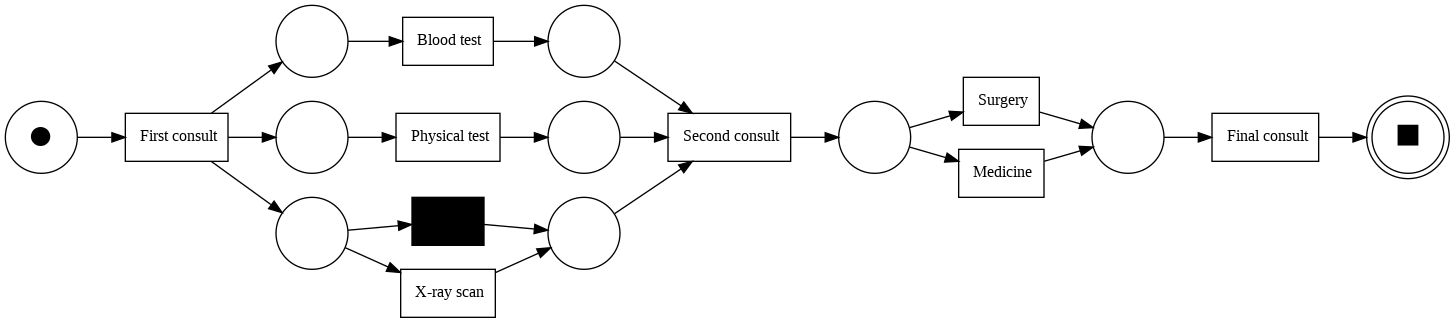

In [78]:
# Visualize the process model as a Petri net, which provides a more detailed representation of the process flow
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(event_log)
pm4py.view_petri_net(net, initial_marking, final_marking)

**Observation:**

Based on what is portrayed in the event log,

* There is an indication that First consult is the first/initial action conducted at the hospital followed by either Blood test, Physical test or X-ray.

* And the last actions undertaken are Medicine and surgery prior to the final action i.e., Final consult.

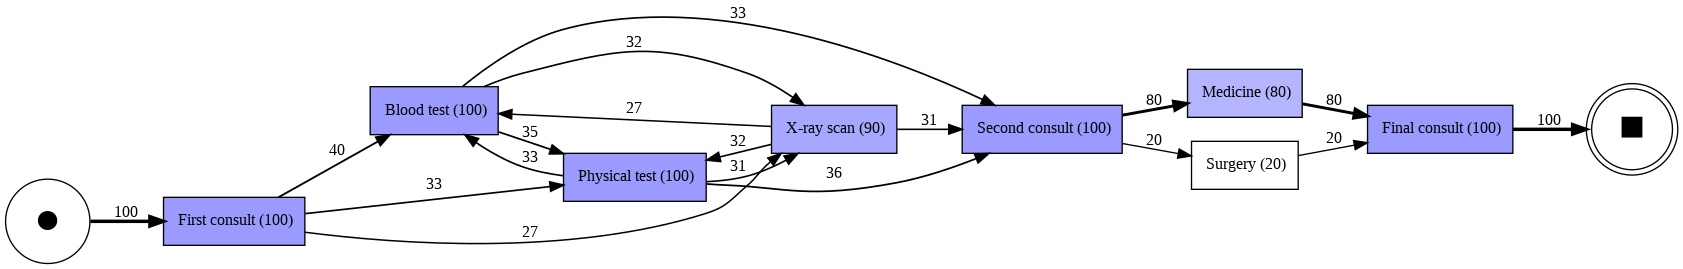

In [79]:
# Visualize the Directly-Follows Graph (DFG), which shows the direct relationships between activities.
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)
pm4py.view_dfg(dfg, start_activities, end_activities)



## Part C: Web Scraping, Puzzle Data, and European News

#### 1. Web Scraping the Wheel of Fortune Puzzle Data

In [80]:
# import necessary libraries
import requests  # requests for making HTTP requests
from bs4 import BeautifulSoup  # BeautifulSoup for parsing HTML
import pandas as pd  # pandas for data manipulation
import matplotlib.pyplot as plt  # matplotlib and seaborn for visualizations
import seaborn as sns
import nltk  # nltk for NLP
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from wordcloud import WordCloud

In [81]:
# Download NLTK resources if not already downloaded
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [82]:
# URL of the Wheel of Fortune answer website
url = "https://wheeloffortuneanswer.com/"

In [83]:
# Send a GET request to the provided URL and parse the HTML content
response = requests.get(url)

In [84]:
# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.content, "html.parser")

In [85]:
# Find / Locate the puzzle categories and answers within the HTML structure
puzzle_categories = []
puzzle_answers = []

In [86]:
# Assuming the puzzles are within divs with a specific class, adjust the class as needed.
puzzle_divs = soup.find_all("div", class_="entry-content") #Adjust class if needed.

In [87]:
for div in puzzle_divs:
    puzzles = div.find_all("p")
    for puzzle in puzzles:
        text = puzzle.text.strip()
        if ":" in text:
            category, answer = text.split(":", 1)
            puzzle_categories.append(category.strip())
            puzzle_answers.append(answer.strip())

In [88]:
# Create a pandas DataFrame
puzzle_data = pd.DataFrame({"Category": puzzle_categories, "Word To Guess": puzzle_answers})

In [89]:
# Save the data to a CSV file
puzzle_data.to_csv("Bisimbeko.csv", index=False)

In [90]:
# Display the first few rows of the DataFrame
print(puzzle_data.head())

  Category                                      Word To Guess
0   Update  Thank you everyone for your valuable feedbacks...


#### 2. Preprocessing and Visualizing the Puzzle Data (Bisimbeko.csv)

In [91]:
# Load the puzzle data
puzzle_data = pd.read_csv("Bisimbeko.csv")

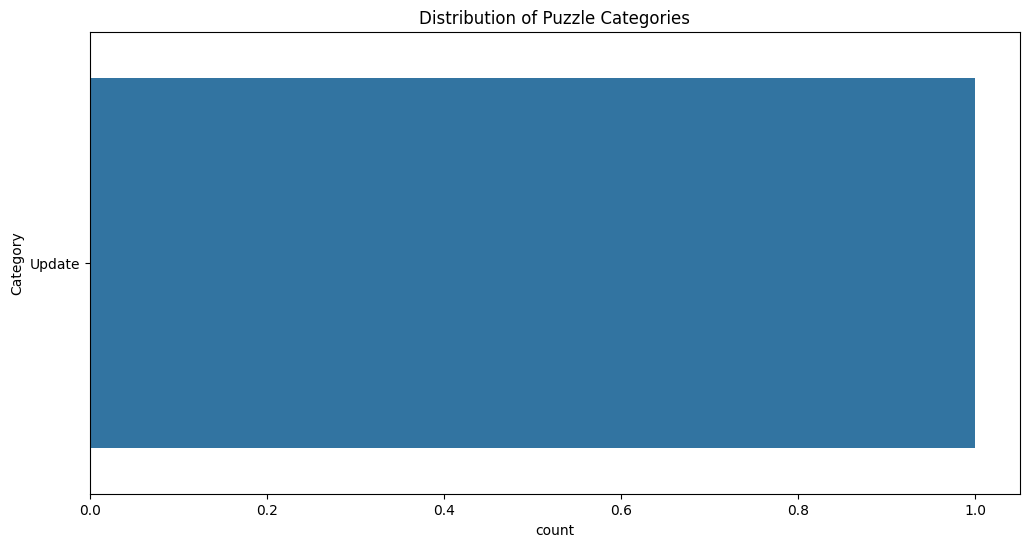

In [92]:
# Use countplot Visualize the distribution of puzzle categories
plt.figure(figsize=(12, 6))
sns.countplot(y="Category", data=puzzle_data, order=puzzle_data["Category"].value_counts().index)
plt.title("Distribution of Puzzle Categories")
plt.show()

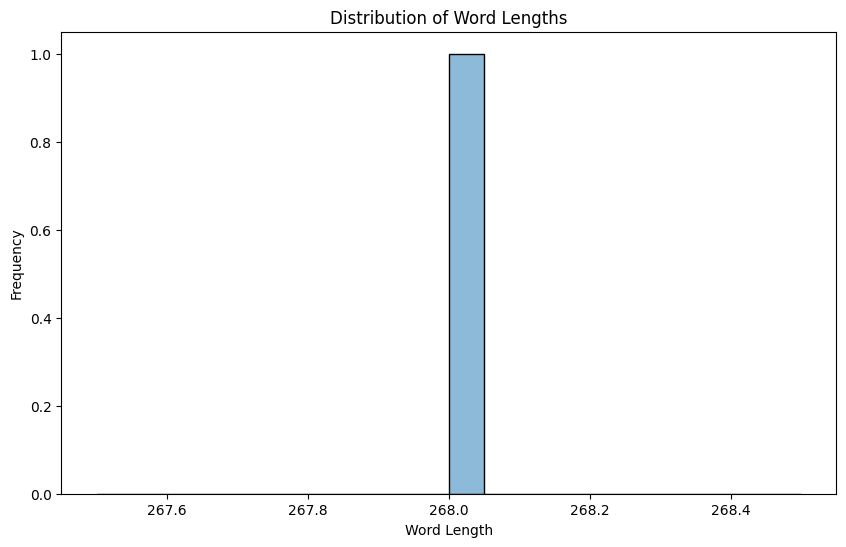

In [93]:
# Create Visualize the length of "Word To Guess"
puzzle_data["Word Length"] = puzzle_data["Word To Guess"].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(puzzle_data["Word Length"], bins=20, kde=True)
plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()

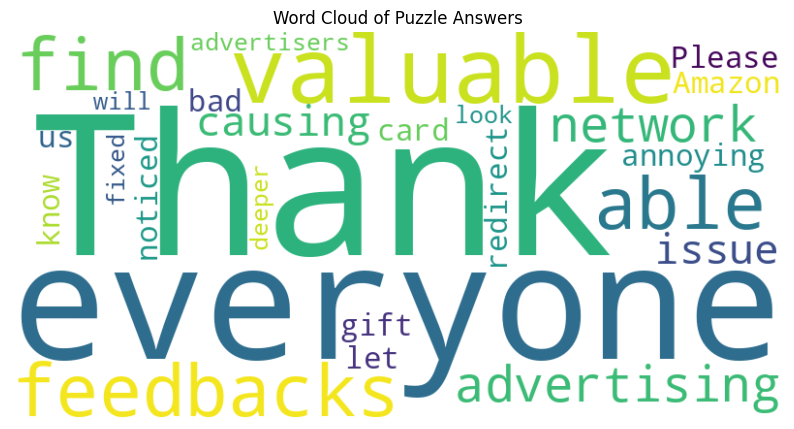

In [94]:
# Generate a word cloud of the puzzle answers
text = " ".join(puzzle_data["Word To Guess"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Puzzle Answers")
plt.show()

**Observation:**

Based on the word cloud, the word cloud answrs are
* Thank
* Everyone
* Valuable


*

In [95]:
# Load the puzzle data
puzzle_data = pd.read_csv("Bisimbeko.csv")

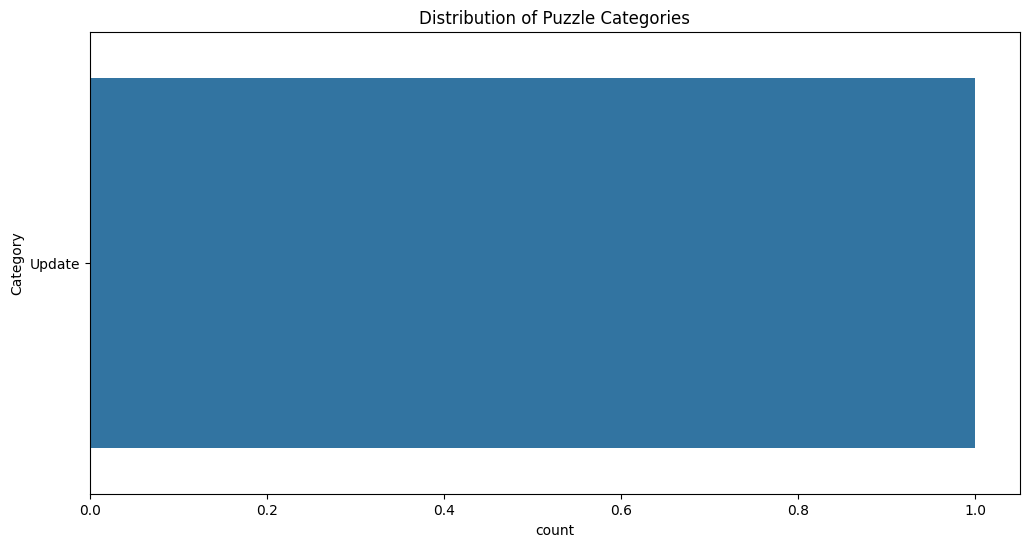

In [96]:
# Visualize the distribution of puzzle categories
plt.figure(figsize=(12, 6))
sns.countplot(y="Category", data=puzzle_data, order=puzzle_data["Category"].value_counts().index)
plt.title("Distribution of Puzzle Categories")
plt.show()

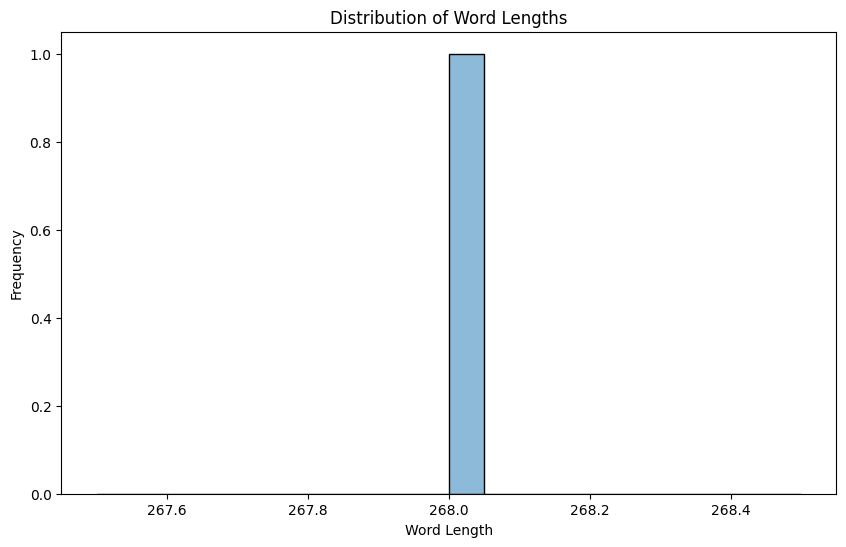

In [97]:
# Visualize the length of "Word To Guess"
puzzle_data["Word Length"] = puzzle_data["Word To Guess"].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(puzzle_data["Word Length"], bins=20, kde=True)
plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()

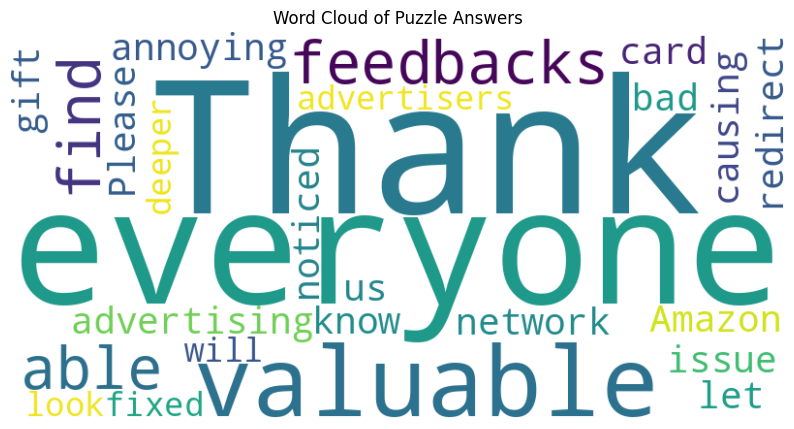

In [98]:
# Generate a word cloud of the puzzle answers
text = " ".join(puzzle_data["Word To Guess"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Puzzle Answers")
plt.show()

#### 3. Preprocessing and Visualizing the European News Data

In [99]:
uploaded = files.upload()

Saving European news.csv to European news.csv


In [100]:
# Load the European news data
news_data = pd.read_csv("European news.csv")

In [101]:
# Check for missing values
print(news_data.isnull().sum())

Articles    0
labels      0
dtype: int64


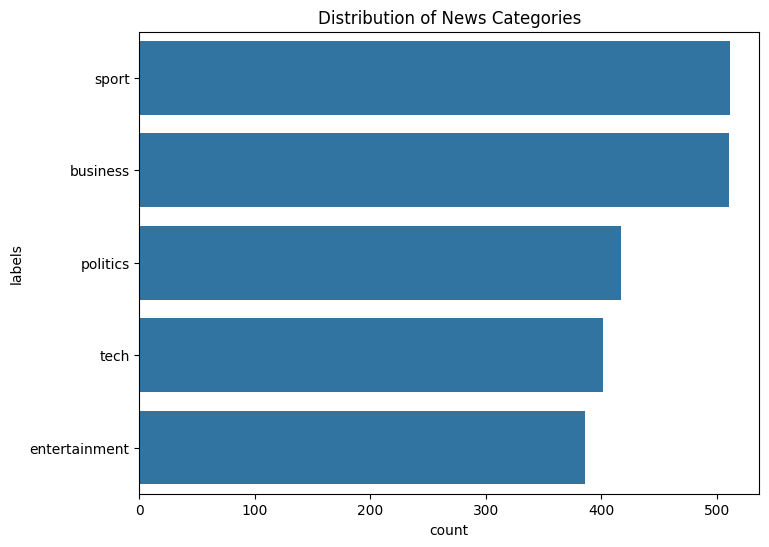

In [102]:
# Visualize the distribution of news categories
plt.figure(figsize=(8, 6))
sns.countplot(y="labels", data=news_data, order=news_data["labels"].value_counts().index)
plt.title("Distribution of News Categories")
plt.show()

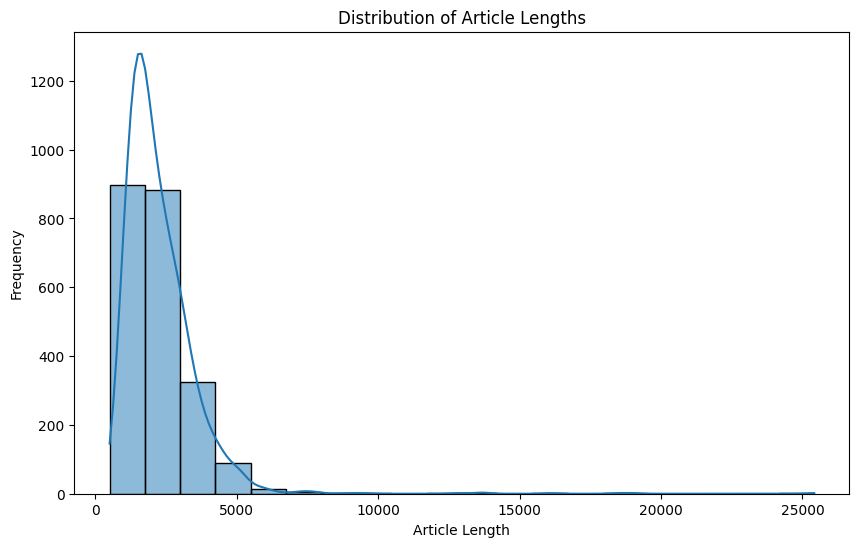

In [103]:
# Visualize the length of news articles
news_data["Article Length"] = news_data["Articles"].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(news_data["Article Length"], bins=20, kde=True)
plt.title("Distribution of Article Lengths")
plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.show()

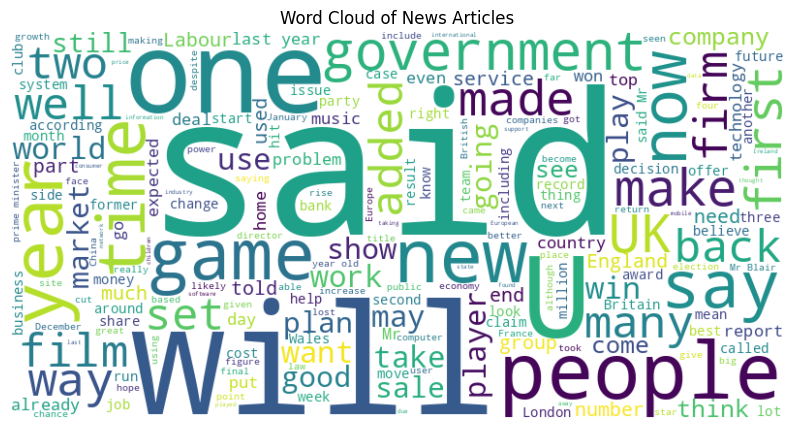

In [104]:
# Generate a word cloud of the news articles
text = " ".join(news_data["Articles"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of News Articles")
plt.show()

#### 4. Natural Language Processing Algorithms for News Classification

In [105]:
# Text preprocessing
stop_words = set(stopwords.words("english"))

In [106]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

nltk.download('wordnet') #download wordnet for lemmatizer.
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [107]:
# Preprocess the news articles by tokenizing, removing stop words, and converting to lowercase
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalnum() and token not in stop_words]
    return " ".join(filtered_tokens)


In [108]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [109]:
# Creating a new column 'Processed_Articles' with preprocess text
news_data['Processed Articles'] = news_data['Articles'].apply(preprocess_text)

In [110]:
# Checking for changes
news_data.head()

,Articles,labels,Article Length,Processed Articles
0,Musicians to tackle US red tape Musicians gro...,entertainment,2254,musician tackle u red tape musician group tack...
1,"U2s desire to be number one U2, who have won ...",entertainment,4799,u2s desire number one u2 three prestigious gra...
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment,2125,rocker doherty fight rock singer pete doherty ...
3,Snicket tops US box office chart The film ada...,entertainment,1052,snicket top u box office chart film adaptation...
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment,1598,ocean twelve raid box office ocean twelve crim...


In [111]:
# Feature extraction using TF-IDF from the preprocessed text
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(news_data["Processed Articles"])
y = news_data["labels"]

In [112]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
# Train and evaluate five NLP models: Naive Bayes, Random Forest, SVM, Logistic Regression, and K-Nearest Neighbors

# 5 NLP Models
models = {
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [114]:
# Train and evaluate models

# Print the classification report for each model, showing precision, recall, F1-score, and support

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))

Model: Naive Bayes
               precision    recall  f1-score   support

     business       0.97      0.98      0.98       103
entertainment       1.00      0.96      0.98        84
     politics       0.92      0.99      0.95        80
        sport       0.99      0.99      0.99        98
         tech       0.99      0.94      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445

Model: Random Forest
               precision    recall  f1-score   support

     business       0.94      0.95      0.95       103
entertainment       1.00      0.99      0.99        84
     politics       0.97      0.97      0.97        80
        sport       0.99      0.98      0.98        98
         tech       0.95      0.96      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       

**THANK** **YOU**
